In [12]:
import os
print(os.getcwd())

c:\Users\chhlg\ai-job-risk-predictor\models


In [13]:
import os
from pathlib import Path
import pandas as pd

BASE_DIR = Path().resolve().parent

DATA_PATH = BASE_DIR / "data" / "processed" / "featured_data.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (3000, 49)


,avg_salary_usd,experience_required_years,task_repetition_level,creativity_requirement,physical_labor_level,analytical_complexity,social_interaction_level,ai_tool_maturity_score,percent_tasks_automatable,job_growth_rate,...,ai_tool_availability_Gemini,ai_tool_availability_Midjourney,automation_pressure,human_resistance,skill_index,ai_readiness,experience_inverse,salary_scaled,job_demand_scaled,job_stability
0,79768,0,0.547871,0.342500,0.380444,0.654976,0.258830,0.945982,0.729611,-0.092463,...,1,0,0.590204,0.431088,0.445538,0.662665,1.000000,0.79768,0.305625,0.106581
1,78128,11,0.023961,0.076849,0.056515,0.061107,0.748744,0.324408,0.504684,-0.072548,...,0,0,0.345710,0.270360,0.049240,0.468234,0.083333,0.78128,0.010505,-0.031022
2,113123,6,0.764220,0.392944,0.677674,0.436737,0.163962,0.347507,0.593449,0.008407,...,0,0,0.676137,0.267422,0.454503,0.636862,0.142857,1.13123,0.165633,0.087020
3,138255,2,0.580914,0.669926,0.328202,0.913109,0.846632,0.870638,0.927684,0.007696,...,0,0,0.665244,0.708324,0.647759,0.880811,0.333333,1.38255,0.725204,0.366450
4,33174,5,0.625590,0.469890,0.467776,0.791285,0.131904,0.129043,0.393783,0.143076,...,0,0,0.445546,0.370768,0.813585,0.149355,0.166667,0.33174,0.004427,0.073752


In [14]:
leakage_cols = ['automation_pressure']

X = df.drop(columns=['automation_risk'] + leakage_cols, errors='ignore')
y = df['automation_risk']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [17]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.023850541143533445
R2: 0.9533416693319594


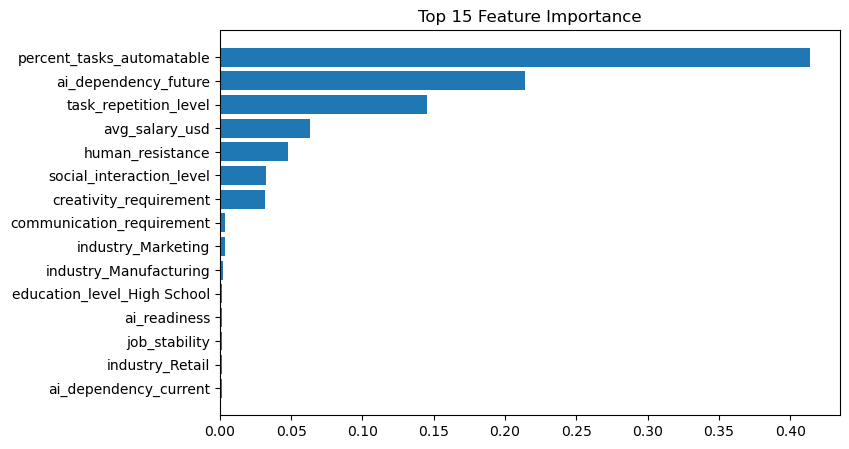

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False).head(15)

plt.figure(figsize=(8,5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importance")
plt.show()

In [19]:
import joblib

MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(model, MODEL_DIR / "model.pkl")
joblib.dump(X.columns.tolist(), MODEL_DIR / "columns.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!
